In [1]:
import scanpy as sc
import anndata as ad
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.colors import ListedColormap, rgb2hex
import numpy as np
import warnings
import pandas as pd
warnings.filterwarnings('ignore')
from sklearn.metrics import jaccard_score
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['pdf.fonttype'] = 42 

from matplotlib.font_manager import fontManager, FontProperties

fontManager.addfont('/data/work/Arial.ttf')

font = FontProperties(fname='/data/work/Arial.ttf')
font_name = font.get_name()
plt.rcParams['font.family'] = font_name
import os

import matplotlib.pyplot as plt
import seaborn as sns
def corr_plot(corr_matrix, save_name, figsize):


    g = sns.clustermap(
        corr_matrix,
        annot=False,
        cmap='coolwarm',
        square=True,
        linewidths=.5,
        cbar_pos=None,          
        dendrogram_ratio=0.15,  
        figsize=figsize,
        row_cluster=True,
        col_cluster=True,
        yticklabels=True,
        xticklabels = True,
        tree_kws={'linewidths': 1.0}
    )

    g.ax_heatmap.yaxis.tick_left()
    g.ax_heatmap.yaxis.set_label_position('left')

    heatmap_pos = g.ax_heatmap.get_position()
    row_dend_pos = g.ax_row_dendrogram.get_position()

    g.ax_row_dendrogram.set_position([heatmap_pos.x1,
                                      row_dend_pos.y0, 
                                     row_dend_pos.width, row_dend_pos.height])

    g.ax_row_dendrogram.invert_xaxis()

    cbar_ax = g.fig.add_axes([heatmap_pos.x1 + 0.2, 0.5, 0.03, 0.2])  
    cbar_ax.set_title('Correlation', fontsize=12, pad=10)
    g.fig.colorbar(g.ax_heatmap.collections[0], cax=cbar_ax)

    g.ax_heatmap.set_xlabel('Mouse Brain celltype', fontsize=14, fontweight='bold')
    g.ax_heatmap.set_ylabel('Lamprey Brain celltype', fontsize=14, fontweight='bold')

    plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right')
    plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0)

    plt.savefig(save_name, bbox_inches = 'tight')
    plt.close()
    
    
import plotly.graph_objects as go
import numpy as np

def plot_sankey_from_corr(corr_matrix, threshold=0.3, output_path=None):

    lamprey_labels = list(corr_matrix.index)
    mouse_labels = list(corr_matrix.columns)
    all_labels = lamprey_labels + mouse_labels
    
    label_to_idx = {label: idx for idx, label in enumerate(all_labels)}
    
    sources = []
    targets = []
    values = []
    colors = []
    
    for i, lamprey_type in enumerate(lamprey_labels):
        for j, mouse_type in enumerate(mouse_labels):
            corr_val = corr_matrix.loc[lamprey_type, mouse_type]
            
            if corr_val > threshold:
                sources.append(label_to_idx[lamprey_type])
                targets.append(label_to_idx[mouse_type])
                values.append(corr_val)
                
                alpha = min(corr_val, 1.0)
                colors.append(f'rgba(31, 119, 180, {alpha})')
    
    node_colors = ['rgba(255, 127, 14, 0.8)'] * len(lamprey_labels) + \
                  ['rgba(44, 160, 44, 0.8)'] * len(mouse_labels)
    
    fig = go.Figure(data=[go.Sankey(
        node=dict(
            pad=15,
            thickness=20,
            line=dict(color="black", width=0.5),
            label=all_labels,
            color=node_colors
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values,
            color=colors
        )
    )])
    
    fig.update_layout(
        title_text="Lamprey-Mouse Cell Type Correlation Sankey",
        font_size=10,
        height=1200,
        width=1000
    )
    
    if output_path:
        if output_path.endswith('.html'):
            fig.write_html(output_path)
        else:
            fig.write_image(output_path)
    
    fig.show()
    return fig




In [2]:
region = '12.ganglia_habenulae_and_thalamus'
adata_path = f'/data/work/22.fusemap/05.stereoalign/05.scvi_new/scvi_result/{region}.h5ad'
corr1_plot_path = f'/data/work/22.fusemap/05.stereoalign/05.scvi_new/01_fig_plots/{region}/corr1.pdf'
sankey1_plot_path = f'/data/work/22.fusemap/05.stereoalign/05.scvi_new/01_fig_plots/{region}/sankey1.html'
corr2_plot_path = f'/data/work/22.fusemap/05.stereoalign/05.scvi_new/01_fig_plots/{region}/corr2.pdf'
sankey2_plot_path = f'/data/work/22.fusemap/05.stereoalign/05.scvi_new/01_fig_plots/{region}/sankey2.html'
corr3_plot_path = f'/data/work/22.fusemap/05.stereoalign/05.scvi_new/01_fig_plots/{region}/corr3.pdf'
sankey3_plot_path = f'/data/work/22.fusemap/05.stereoalign/05.scvi_new/01_fig_plots/{region}/sankey3.html'
os.makedirs(f'/data/work/22.fusemap/05.stereoalign/05.scvi_new/01_fig_plots/{region}/', exist_ok=True)

In [3]:
adata = sc.read_h5ad(adata_path)
dic = {
    '1': 'mouse',
    '0': 'lamprey',
}

adata.obs['species'] = [dic[i] for i in adata.obs['species']]

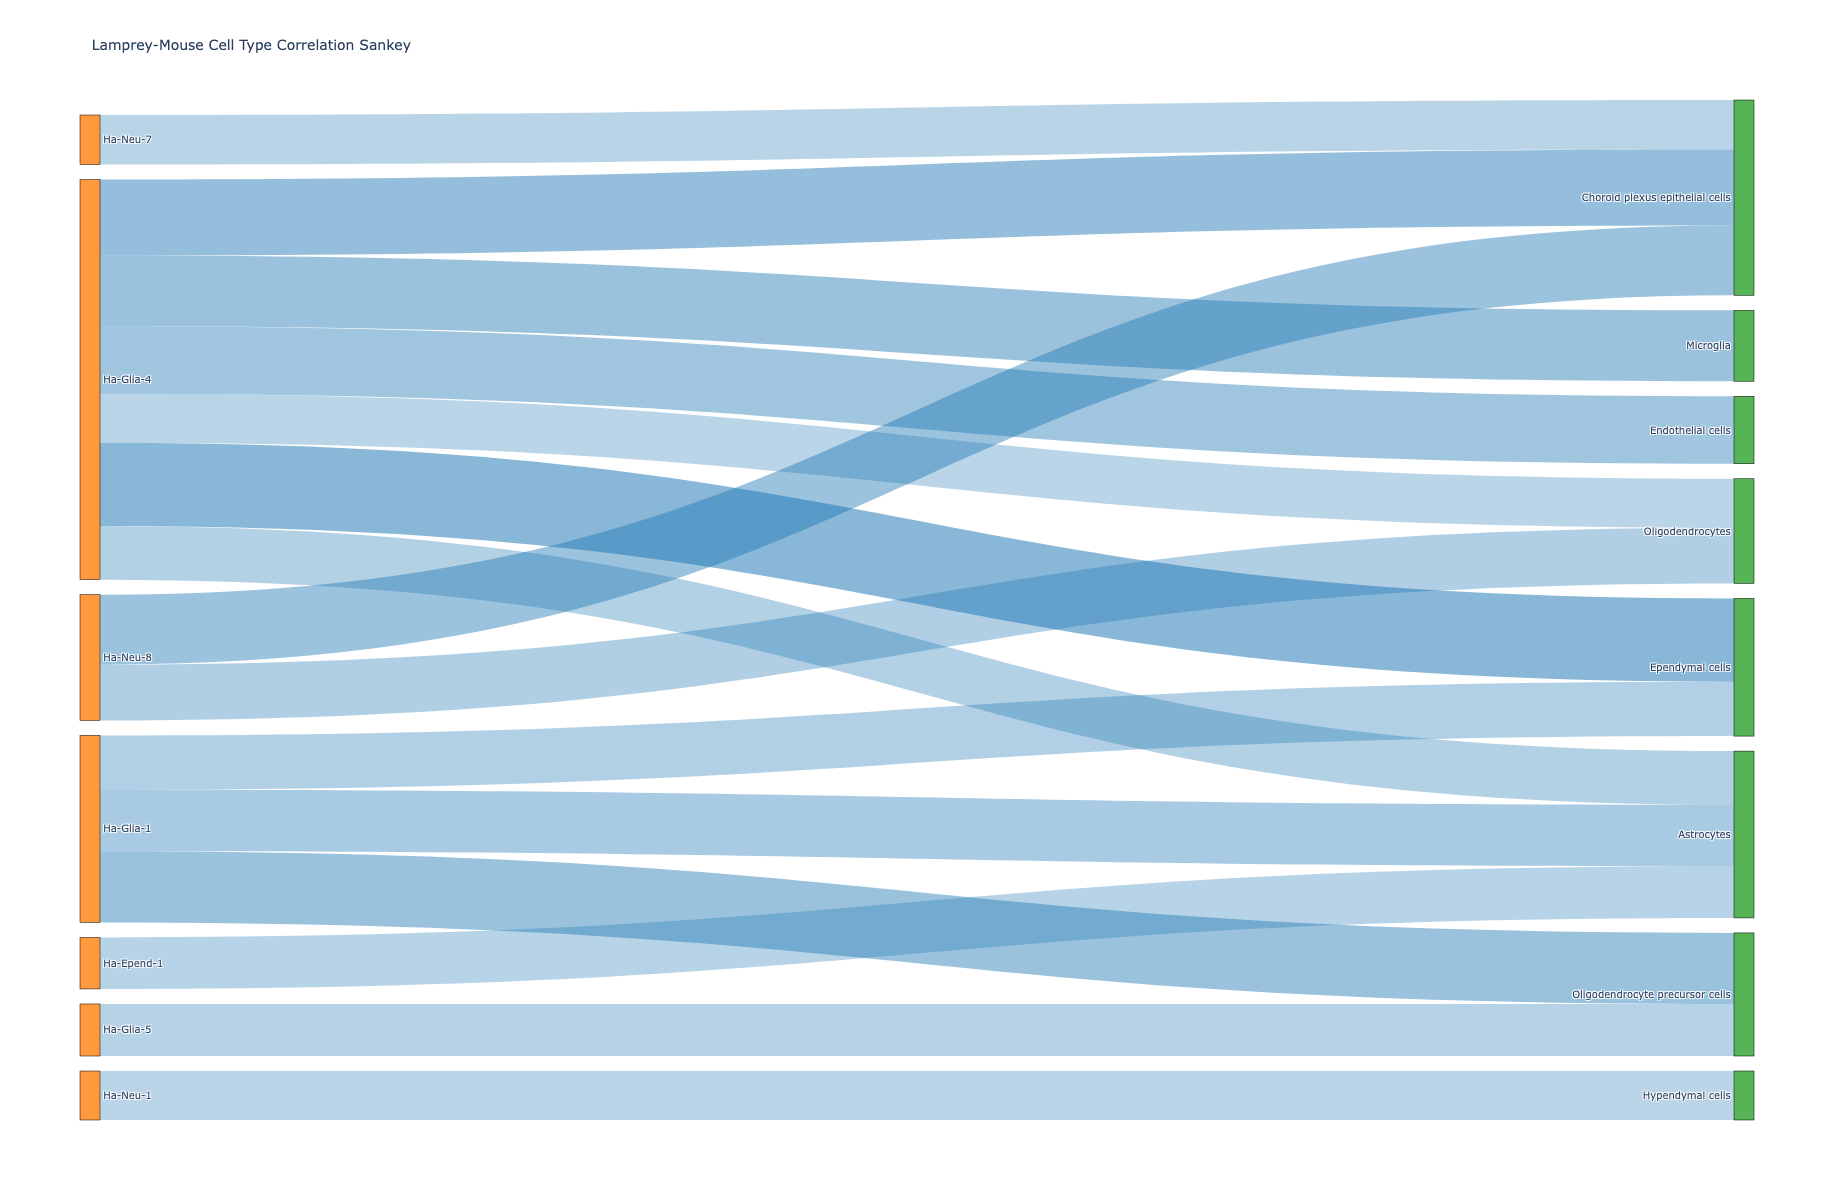

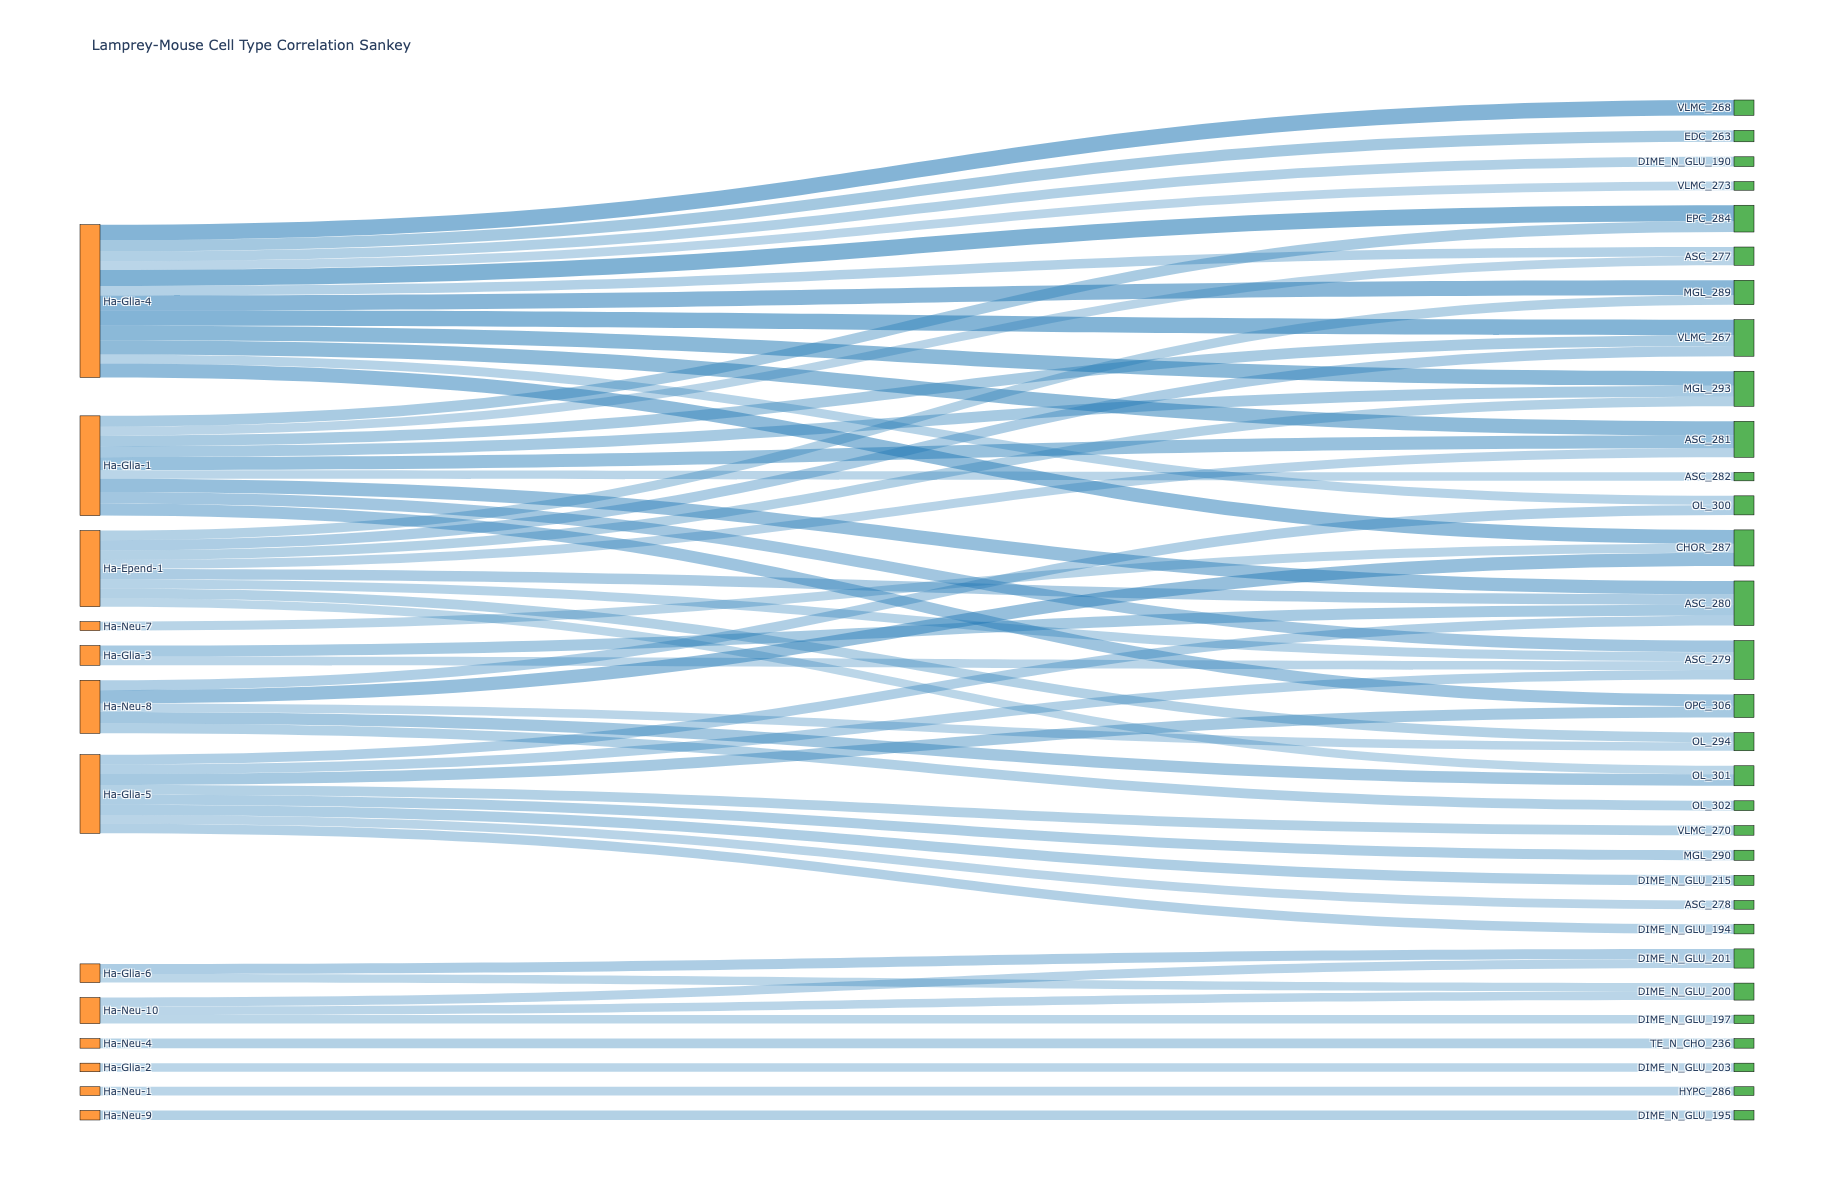

In [6]:
## plot 1
df = pd.DataFrame(adata.obs['celltype'].value_counts())
df = df[df['celltype']>50]
temp = adata[adata.obs['celltype'].isin(df.index.tolist())]
temp.obs['celltype'] = temp.obs['species'].astype(str) +'_'+ temp.obs['celltype'].astype(str)
all_celltypes = list(set(temp.obs['celltype']))
raw_indexs = [i for i in all_celltypes if i.startswith('lamprey')]
raw_columns = [i for i in all_celltypes if i.startswith('mouse')]
scvi_repr = temp.obsm['aligned_scvi']
cell_types = temp.obs['celltype'].values
df = pd.DataFrame(scvi_repr, index=temp.obs.index)
df['cell_type'] = cell_types
mean_repr = df.groupby('cell_type').mean()
corr_matrix = mean_repr.T.corr('pearson')
corr_matrix = corr_matrix[raw_columns].loc[raw_indexs]
corr_matrix.index = [i.replace('lamprey_', '') for i in corr_matrix.index]
corr_matrix.columns = [i.replace('mouse_', ' ') for i in corr_matrix.columns]
corr_plot(corr_matrix, corr1_plot_path, (6,6))
fig = plot_sankey_from_corr(corr_matrix, threshold=0.3, )
fig.write_html(sankey1_plot_path)


## plot 2
df = pd.DataFrame(adata.obs['new_celltype'].value_counts())
df = df[df['new_celltype']>50]
temp = adata[adata.obs['new_celltype'].isin(df.index.tolist())]
temp.obs['new_celltype'] = temp.obs['species'].astype(str) +'_'+ temp.obs['new_celltype'].astype(str)
all_celltypes = list(set(temp.obs['new_celltype']))
raw_indexs = [i for i in all_celltypes if i.startswith('lamprey')]
raw_columns = [i for i in all_celltypes if i.startswith('mouse')]
scvi_repr = temp.obsm['aligned_scvi']
cell_types = temp.obs['new_celltype'].values
df = pd.DataFrame(scvi_repr, index=temp.obs.index)
df['cell_type'] = cell_types
mean_repr = df.groupby('cell_type').mean()
corr_matrix = mean_repr.T.corr('pearson')
corr_matrix = corr_matrix[raw_columns].loc[raw_indexs]
corr_matrix.index = [i.replace('lamprey_', '') for i in corr_matrix.index]
corr_matrix.columns = [i.replace('mouse_', ' ') for i in corr_matrix.columns]
corr_plot(corr_matrix, corr2_plot_path, (18,6))
fig = plot_sankey_from_corr(corr_matrix, threshold=0.3, )
fig.write_html(sankey2_plot_path)

